Cette partie a pour but de  : 
- Récupérer les caractéristiques des stations météos de type 2 de la région Grand Est via l'API et stocker les données dans Cassandra 
- Récupérer les données concernant la consommation électrique en région Grand Est et les stocker dans Cassandra

### 0- Chargement  des packages et création des dossiers nécessaires : 

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType, DateType,time
from pyspark.sql.functions import year, month, dayofweek, hour, udf, lit, col

# Création de la session Spark avec le connecteur Cassandra
spark = SparkSession.builder \
    .appName("Prédiction_conso_elec") \
    .config("spark.cassandra.connection.host", "172.17.0.3") \
    .config("spark.cassandra.connection.port", "9042") \
    .getOrCreate()


# Remplacement de "172.17.0.3" par "172.17.0.2" le 2901

In [2]:
#Import des bibliothèques ;
# Bibliothèque classique : 

import pandas as pd
import os
import json
import requests
import time
from io import BytesIO

In [3]:
#Afin de ne pas afficher certains messages :
import warnings
from requests.packages.urllib3.exceptions import InsecureRequestWarning
# Ignorer les avertissements spécifiques
warnings.filterwarnings('ignore', category=InsecureRequestWarning)
# Pour afficher plus de 50 lignes
pd.set_option('display.max_rows', 200) 

In [5]:
# On créé les dossiers nécessaires en local
if not os.path.exists("Fichiers"):  
    os.mkdir("Fichiers")
if not os.path.exists("Stations"):  
    os.mkdir("Stations")
if not os.path.exists("Stations/Listes"):  
    os.mkdir("Stations/Listes")

In [4]:
#On scrappe les données sur le site  https://www.regions-departements-france.fr/ afin d'obtenir les numéros de département
page_departements = pd.read_html("https://www.regions-departements-france.fr/", header =0)
tableau_regions=page_departements[3]
#tableau_regions.to_csv('Fichiers/1_Departement_et_Region.csv', index=False)
#La corse a un format spécifique et accepte difficillement la conversion en int, on supprime cette région
tableau_regions[tableau_regions.Région!='Corse'].to_csv('Fichiers/1_Departements_et_Regions.csv', index=False)   

### 1- Création de plusieurs fonctions :

#### a- Imputation du dataframe spark et la médiane

In [5]:
from pyspark.ml.feature import Imputer
from pyspark.sql.functions import isnan, when, count, col
from pyspark.sql import functions as F


def verifcontientvaleurnull(data) :
    #test = data.filter(col("t").isNull()).count() + data.filter(col("tx").isNull()).count() + data.filter(col("tn").isNull()).count()
    test = data.filter(col("t").isNull()).count()
    print(test)
    return test
        

def imputation(data) : 
    #imputer = Imputer(inputCols=['t','tx','tn'], outputCols=["t_imputed","tx_imputed","tn_imputed"]).setStrategy("median")
    imputer = Imputer(inputCols=['t'], outputCols=["t_imputed"]).setStrategy("median")
    df_imputed = imputer.fit(data).transform(data)
    df_imputed= df_imputed.drop('t')
    df_imputed= df_imputed.withColumnRenamed("t_imputed","t")
    return(df_imputed)

#### b- Fonction udf pour retourner le numéro de saison 

In [4]:
def return_saison(data):
    print (data)
    #Hiver
    if data in [12,1,2]:
        return 4
    #Printemps
    if data in [3,4,5]:
        return 3
    #Ete
    if data in [6,7,8]:
        return 2
    #Automne
    if data in [9,10,11]:
        return 1

# Converting function to UDF 
UDFreturn_saison = udf(lambda data: return_saison(data), IntegerType())

### 2- Récupération des données

#### a- Classe pour se connecter à l'API Climatique de météo France et récupérer les données des stations climatiques

In [8]:
#Connexion à l'API Climatique afin de stocker certaines données dans Cassandra: 
from io import StringIO
from pyspark.sql.functions import col, regexp_replace, round
from pyspark.sql.types import FloatType
from pyspark.sql.types import DecimalType
#Il est nécessaire de créer un compte sur le portail api de meteofrance afin de générer un id : https://portail-api.meteofrance.fr/
APPLICATION_ID = 'mon_id'
# url to obtain acces token
TOKEN_URL = "https://portail-api.meteofrance.fr/token"

class Client(object):

    def __init__(self):
        self.session = requests.Session()

    def request(self, method, url, **kwargs):
        # First request will always need to obtain a token first
        if 'Authorization' not in self.session.headers:
            self.obtain_token()

        # Optimistically attempt to dispatch request
        response = self.session.request(method, url, **kwargs)
        if self.token_has_expired(response):
            # We got an 'Access token expired' response => refresh token
            self.obtain_token()
            # Re-dispatch the request that previously failed
            response = self.session.request(method, url, **kwargs)
        return response

    def token_has_expired(self, response):
        status = response.status_code
        content_type = response.headers['Content-Type']
        repJson = response.text
        if status == 401 and 'application/json' in content_type:
            repJson = response.text
            if 'Invalid JWT token' in repJson['description']:
                return True
        return False

    def obtain_token(self):
        # Obtain new token
        data = {'grant_type': 'client_credentials'}
        headers = {'Authorization': 'Basic ' + APPLICATION_ID}
        access_token_response = requests.post(TOKEN_URL, data=data, verify=False, allow_redirects=False, headers=headers)
        token = access_token_response.json()['access_token']
        # Update session with fresh token
        self.session.headers.update({'Authorization': 'Bearer %s' % token})
    

    def recuperer_liste_stations_horaires(self, nom_region):
        # 1 Recherche des départements de la région 
        tableau_region = pd.read_csv('Fichiers/1_Departements_et_Regions.csv',dtype={'N°':int, 'Département':str, 'Région':str})
        region = tableau_region[tableau_region.Région==nom_region]
        departements = list(region.iloc[:,0])
        # 2 Boucle pour récupérer les stations de la région concernée et les stocker dans la table dédiée Cassandra
        for numeroDepartement in departements :
            response = self.request('GET', 'https://public-api.meteofrance.fr/public/DPClim/v1/liste-stations/horaire?id-departement='+str(numeroDepartement), verify=False)
            content = json.loads(response.content)
            stations = spark.createDataFrame(content)
            stations = stations.select(stations.id, stations.lat, stations.lon).filter(stations.posteOuvert==True).filter(stations.typePoste=='2')
            stations = stations.withColumn('region',lit(nom_region)).withColumn('departement', lit(numeroDepartement))
            stations = stations.select('region','id','departement','lat','lon')
            stations = stations.withColumnRenamed('id','id_station').withColumnRenamed('lat','latitude').withColumnRenamed('lon','longitude')
            print(stations)
            stations.write.format("org.apache.spark.sql.cassandra").options(table="stations_par_region", keyspace="consom") \
            .mode("append") \
            .save()
            #Un temps d'attente est nécessaire, sinon le code peut retourner une erreur par les serveurs météo France
            time.sleep(3)
            
    def recuperer_valeurs_horaires_stations_sans(self,region, date_debut,date_fin):
        # Chargement de la listes des stations enregistrées dans Cassandra pour la région choisie : 
        listes_stations = spark.read.format("org.apache.spark.sql.cassandra").options(table="stations_par_region", keyspace="consom").load() 
        listes_stations = listes_stations.select("id_station").where(col("region") == region).collect()
        #Chargement des mesures déjà récupérées :  
        mesures_stations = spark.read.format("org.apache.spark.sql.cassandra").options(table="mesures_stations", keyspace="consom").load() 
        mesures_stations = mesures_stations.select("id_station").distinct().collect()
        #On récupère seulement les stations absentes afin de ne pas relancer toutes les requêtes sur l'API : 
        listes_stations = [element for element in listes_stations if element not in mesures_stations]
        for i in listes_stations :
               print(i['id_station'])  
        for ligne in listes_stations:
            try :
                response = self.request('GET', 'https://public-api.meteofrance.fr/public/DPClim/v1/commande-station/horaire?id-station='+ligne['id_station']+'&date-deb-periode='+date_debut+'&date-fin-periode='+date_fin, verify=False)
                # Lire le contenu du fichier CSV
                response_json = json.loads(response.content)
                # On récupère l'id de la commande (c'est une API asynchrone)
                id_commande = response_json.get('elaboreProduitAvecDemandeResponse').get('return')
                #On met en pause 10 seconde afin que le paquet soit mis à disposition sur le serveur avant de lancer la commande
                time.sleep(10)
                #On récupère les données avec la commande de la station cible: 
                fichier_recup =  self.request('GET', 'https://public-api.meteofrance.fr/public/DPClim/v1/commande/fichier?id-cmde='+id_commande,verify=False)
                if fichier_recup.status_code == 201:
                    print("201")
                    content = fichier_recup.content.decode('utf-8')
                    csv_file = StringIO(content)
                    df_pandas = pd.read_csv(csv_file, delimiter=';')
                    df_pandas["DATE"] = pd.to_datetime(df_pandas["DATE"], format='%Y%m%d%H')
                    dataf = spark.createDataFrame(df_pandas)
                    #On effectue l'ensemble des opérations avant écriture dans la base de données : 
                    dataf= dataf.withColumn('saison', UDFreturn_saison(month(dataf["DATE"]))).withColumn('annee', year(dataf["DATE"])).withColumn('mois', month(dataf["DATE"])).withColumn('jour', dayofweek(dataf["DATE"])).withColumn('heure', hour(dataf["DATE"])) \
                    .withColumnRenamed('POSTE','id_station')
                    dataf = dataf.withColumnRenamed('DATE','timestamp')
                    #Conversion de la virgule en point + conversion de type en decimal car soucis avec le float
                    decimal_type = DecimalType(10, 1)
                    #Ajout de la colonne id_station car soucis avec les 0 
                    dataf  = dataf.withColumn("id_station", lit(str(ligne['id_station'])))
                    dataf = dataf.withColumn('t',round(regexp_replace(col('t'), "\\,", ".").cast(decimal_type),1)) \
                    .withColumn('tn',round(regexp_replace(col('tn'), "\\,", ".").cast(decimal_type),1)) \
                    .withColumn('tx',round(regexp_replace(col('tx'), "\\,", ".").cast(decimal_type),1))
                    dataf = dataf.select('id_station','timestamp','saison','annee','mois','jour','heure','t')
                    #On écrit dans la base mais préalablement, on test la colonne t la régle étant d'écarter les stations qui ont des données absente sur 60 h
                    Nbnull = verifcontientvaleurnull(dataf)
                    if (Nbnull <60) :
                        if (Nbnull>0):
                            #On impute:
                            print("imputation de "+ligne['id_station']+" avec "+str(Nbnull)+" valeurs manquantes")
                            dataf = imputation(dataf)    
                                
                        try : 
                            print("j'écris pour"+ligne['id_station'])
                            dataf.write.format("org.apache.spark.sql.cassandra").options(table="mesures_stations", keyspace="consom") \
                            .mode("append") \
                            .save()
                        except Exception as e:
                            erreur = f"Erreur lors de l'écriture dans Cassandra : {str(e)}"
                            print(erreur)
                        #On sauvegarde également dans un fichier csv local : 
                        try :
                            filename = 'Stations/2025/Stations/Mesures/'+ligne['id_station']+'.csv'
                            datapanda = dataf.toPandas()
                            datapanda.to_csv(filename, index=False, sep=';')
                            print("Fichier pour station créé")
                        except Exception as e:
                            error_message = f"Erreur fichier csv : {str(e)}"
                            print(error_message)
                    else : 
                        print("station"+ ligne['id_station'] +" est écartée elle a  trop de valeur manquante")
                else :
                    print(fichier_recup.status_code)
                    print('erreur avec la station :'+ ligne['id_station'])
            except Exception as e:
                print(f"Une erreur est survenue : {e}")
                
def main():
    client = Client()
    client.session.headers.update({'Accept': 'application/json'})
     #1 On récupère toutes les statiosn en grand est et 2- on récupère les mesures des stations pendant un an    
    #client.recuperer_liste_stations_horaires(nom_region='Grand Est)
    client.recuperer_valeurs_horaires_stations_sans(region='Grand Est', date_debut='2024-01-01T00:00:00Z', date_fin='2024-12-31T23:00:00Z')

if __name__ == '__main__':
    main()

08207001
10042001
201
ok
334
station08207001 est écartée elle a  trop de valeur manquante
201
ok
264
station10042001 est écartée elle a  trop de valeur manquante


#### b- Récupération de la consommation electrique régionale

Comme il y a quelque problèmes avec l'API dédiée, nous nous contentons de télécharger les données historisées et de les ouvrir dans un dataframe, elles sont nettoyées, imputées et mises à une échelle horaire. Pour finir nous les chargeons dans Cassandra. <br>
A noter que le code ci-dessous est dédié à la région Grand Est. Il suffit de modifier légérement pour récupérer rapidement les mêmes données pour toutes les régions. 

In [54]:
#On ouvre le fichier et on renomme les colonnes : 
odrepd= pd.read_csv('Eco2mix/GE2024.csv', sep=';').loc[:,['Région','Date - Heure','Consommation (MW)']]
odrepd.rename(columns={'Région':'region','Date - Heure':'dateconso','Consommation (MW)':'consommation'},inplace=True)
#on supprime les duplications : 
odrepd=odrepd.drop_duplicates()
#On réordonne les lignes et on supprime l'indicateur GMT car il ne supporte pas la conversion en datetime
odrepd=odrepd.sort_values('dateconso')
odrepd['dateconso']= odrepd['dateconso'].apply(lambda x: x[:-6])
odrepd['dateconso'] = pd.to_datetime(odrepd['dateconso'],errors='coerce')
#Quelques centaines de valeurs sont à 0 ou NA dans le dataframe.
#On converti les valeur 0 en NA :
odrepd['consommation'] = odrepd['consommation'].apply(lambda x: None if x == 0 else x)
#A ce stade, on impute simplement par la médiane
odrepd['consommation'] = odrepd['consommation'].fillna(odrepd['consommation'].median())
#On change le type de consommation de float en int : 
odrepd['consommation'] = odrepd['consommation'].astype(int)
odrepd.set_index("dateconso", inplace=True)
## On rééchantillone des données toutes les heures puis on supprime l'index 
odrepd_aggregated = odrepd.resample('H').sum().reset_index()
#on supprime les 0 qui ont été créée : 
odrepd_aggregated = odrepd_aggregated.loc[odrepd_aggregated['consommation'] != 0]
odrepd_aggregated[odrepd_aggregated['consommation'] ==0]

,dateconso,region,consommation


On vérifie visuellement les valeurs :

15174.0
      region  consommation                  dateconso
0  Grand Est       15174.0  2024-03-31 02:00:00+00:00


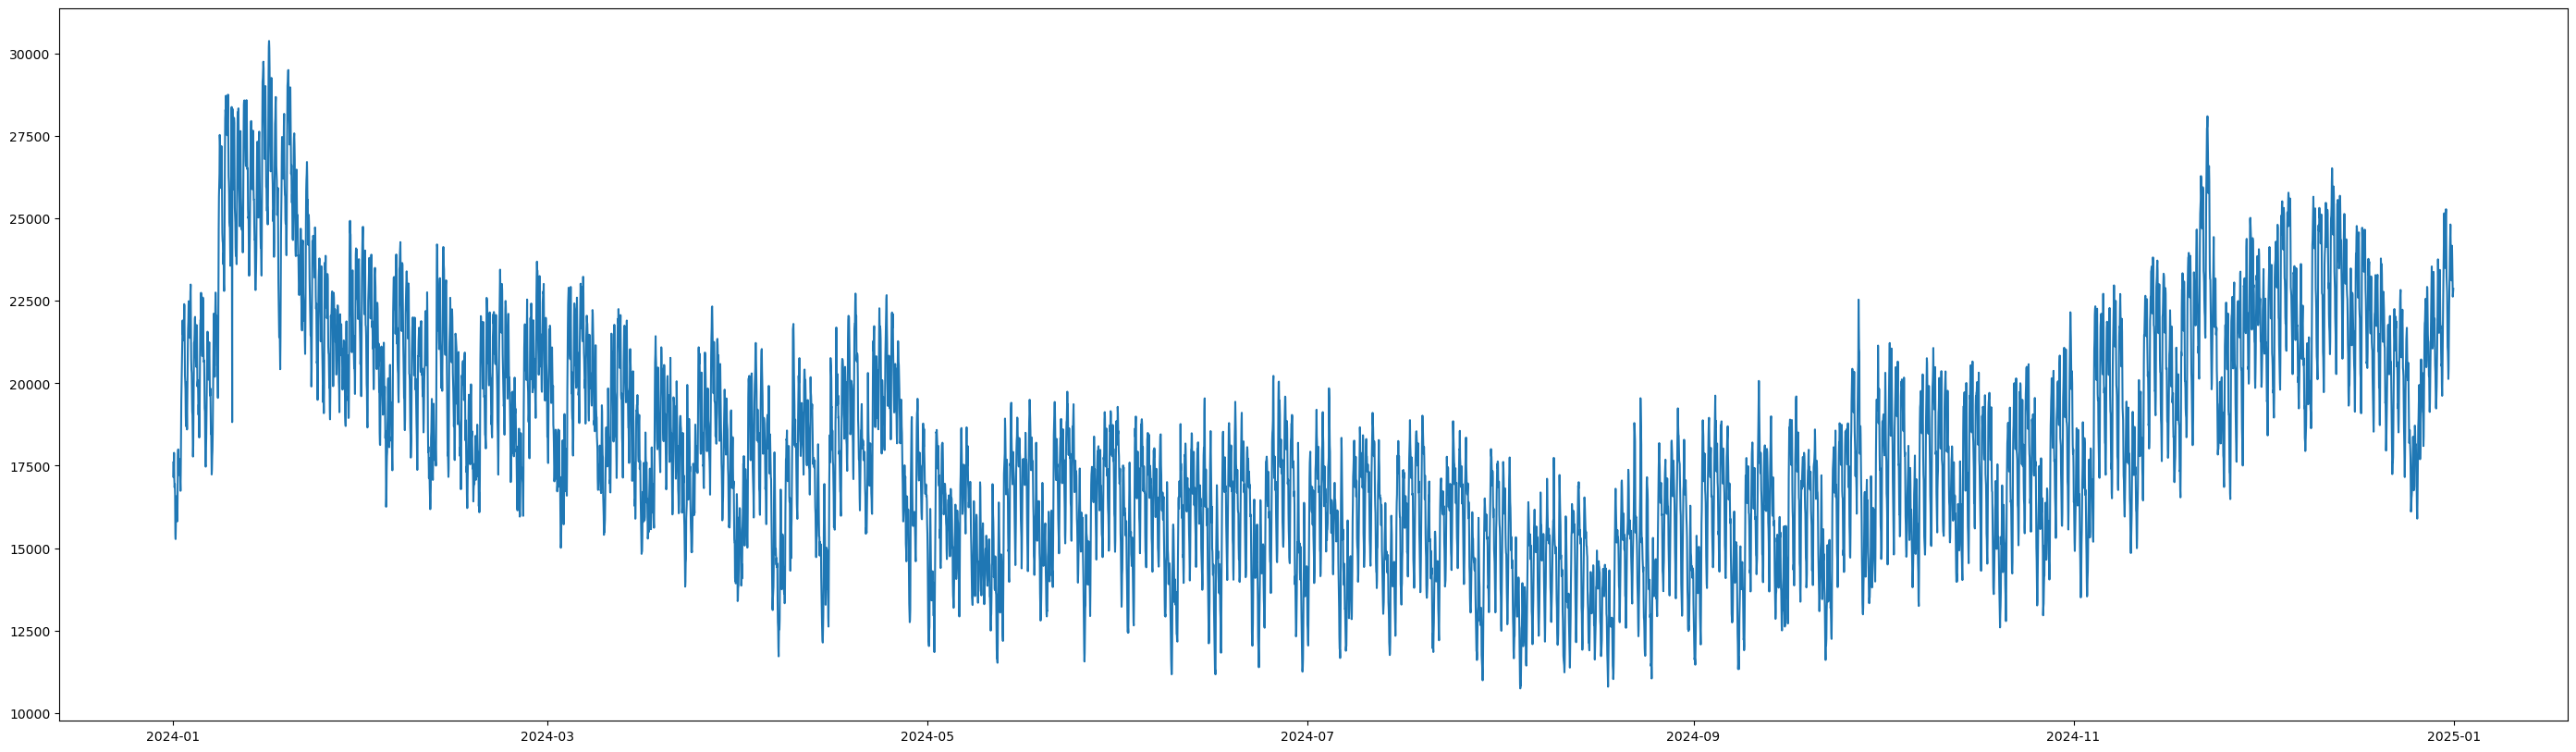

In [55]:
#On affiche le graphique avec pyplot : 
import matplotlib.pyplot as plt 
#Une valeur extreme apparait le 31 mars 2024 à 3h car elle est dû au changement d'heure.
#On traite cette valeur extrème et on ajoute la ligne manquante à 2h du matin dont la consommation est une simple division 
valeurmars2023 = odrepd_aggregated.loc[odrepd_aggregated["dateconso"]== '2024-03-31 03:00:00','consommation']
print(valeurmars2023.iloc[0]/2)
odrepd_aggregated.loc[odrepd_aggregated['dateconso'] == pd.to_datetime('2024-03-31 03:00:00'), 'consommation']=valeurmars2023.iloc[0] / 2
new_ligne = pd.DataFrame({"region":["Grand Est"],"consommation":[valeurmars2023.iloc[0]/2],"dateconso":["2024-03-31 02:00:00+00:00"]})
print(new_ligne)
odrepd_aggregated= pd.concat([odrepd_aggregated,new_ligne],ignore_index=True)
#On modifie la valeur de Grand Est : 
odrepd_aggregated['region']='Grand Est'
# On trie le DataFrame par la colonne 'dateconso'
odrepd_aggregated['dateconso'] = pd.to_datetime(odrepd_aggregated['dateconso'],errors='coerce')
odrepd_aggregated= odrepd_aggregated.sort_values('dateconso')
plt.figure(figsize=[35,10])
plt.plot(odrepd_aggregated["dateconso"],odrepd_aggregated["consommation"])

Pour résumer, les données horaires récupérées de Eco2mix contiennent des données et même des obervations manquantes, plusieurs  centaines de 0 et de NA étaient présents. Les  différentes valeurs ont été imputées via la médiane. 

In [61]:
sparkpd = spark.createDataFrame(odrepd_aggregated)
sparkpd= sparkpd.withColumnRenamed('dateconso','timestamp')
sparkpd= sparkpd.withColumn('annee', year(sparkpd['timestamp']))

sparkpd.take(5)

[Row(timestamp=datetime.datetime(2024, 1, 1, 0, 0), region='Grand Est', consommation=17600.0, annee=2024),
 Row(timestamp=datetime.datetime(2024, 1, 1, 1, 0), region='Grand Est', consommation=17147.0, annee=2024),
 Row(timestamp=datetime.datetime(2024, 1, 1, 2, 0), region='Grand Est', consommation=17415.0, annee=2024),
 Row(timestamp=datetime.datetime(2024, 1, 1, 3, 0), region='Grand Est', consommation=17890.0, annee=2024),
 Row(timestamp=datetime.datetime(2024, 1, 1, 4, 0), region='Grand Est', consommation=17077.0, annee=2024)]

In [62]:
#Pour finir, on stocke les données de la région dans la table cassandra : 
#sparkpd = spark.createDataFrame(odrepd_aggregated)
sparkpd.write.format("org.apache.spark.sql.cassandra").options(table="consommation_elec_reelle", keyspace="consom") \
                         .mode("append") \
                        .save()

En conclusion, dans cette partie : 
- Nous avons récupéré les caractéristiques des stations météos de type 2 de la région Grand Est (Plus de 113 stations actives)
- les données de ces stations météos ont été récupérées via l'API dédiée puis elles ont été chargées dans Cassandra après les avoir nettoyées et imputées par la médiane. Ces opérations dû à la contrainte de l'API  de météo France (asynchrone) a pris un peu moins de 40 minutes.
- les données de Eco2mix ont été récupérées, nettoyées, imputées et réechantillonées sur une échelle de temps similaires aux données climatiques (pas de temps d'une heure).
Pour finir les données ont été chargées dans une table dédiée Cassandra

In [9]:
spark.stop()